# 06 · Selección del docente

Compara los 5 candidatos a docente y promueve al mejor: el que sirve
`streamlit_app.py` por defecto y el que las notebooks de destilación usan
como docente.

**Criterio: mayor macro-F1 en `test`, sin mirar costo.** El docente no se
despliega — su trabajo es marcar el techo de calidad y transferirlo. El costo
sí se mide aquí, pero solo como contexto para leer la tabla; quien se elige
por costo es el estudiante (`01_student/05`).

Macro-F1 y no accuracy porque el corpus está desbalanceado: accuracy premia
acertar las especies abundantes.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import pandas as pd
import tensorflow as tf

from scripts import evalStats
from scripts import modelRegistry as registro
from scripts.architectures import DOCENTES
from scripts.vizStyle import INK_MUTED, SERIE_1, SERIE_2, SERIE_3, applyStyle

ROL = "docente"

runs = registro.listRuns()
runPorArquitectura = {}
for run in runs:
    arquitectura = run.get("architecture")
    if run.get("role") == ROL and arquitectura in DOCENTES and arquitectura not in runPorArquitectura:
        runPorArquitectura[arquitectura] = run

faltantes = [a for a in DOCENTES if a not in runPorArquitectura]
if faltantes:
    print("Sin run registrado todavía:", faltantes)
print(f"{len(runPorArquitectura)} de {len(DOCENTES)} candidatos entrenados")

Sin run registrado todavía: ['efficientnet_v2_s']
4 de 5 candidatos entrenados


## 1 · Calidad y costo de cada candidato

In [3]:
filas = []
for arquitectura, run in runPorArquitectura.items():
    ruta = registro.runDir(run["run_id"]) / "model.keras"
    modelo = tf.keras.models.load_model(ruta)
    filas.append({
        "arquitectura": arquitectura,
        "test_accuracy": run["test_accuracy"],
        "test_macro_f1": run["test_macro_f1"],
        "parametros_M": round(modelo.count_params() / 1e6, 2),
        "tamano_MB": round(ruta.stat().st_size / 1e6, 1),
        "latencia_ms": round(evalStats.medirLatencia(modelo), 1),
        "minutos_entrenamiento": run["training_minutes"],
        "run_id": run["run_id"],
    })

comparacion = pd.DataFrame(filas).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparacion

,arquitectura,test_accuracy,test_macro_f1,parametros_M,tamano_MB,latencia_ms,minutos_entrenamiento,run_id
0,efficientnet_v2_b0,0.814258,0.802046,6.75,34.7,122.6,183.6,20260902T015532Z_efficientnet-v2-b0
1,resnet50_v2,0.792919,0.787120,24.79,109.7,135.8,449.7,20260904T023029Z_resnet50-v2
2,densenet121,0.793404,0.784358,7.74,38.1,212.7,494.7,20260905T020047Z_densenet121
3,inception_v3,0.724054,0.710476,23.03,103.1,134.9,412.7,20260906T040431Z_inception-v3


## 2 · Accuracy vs macro-F1

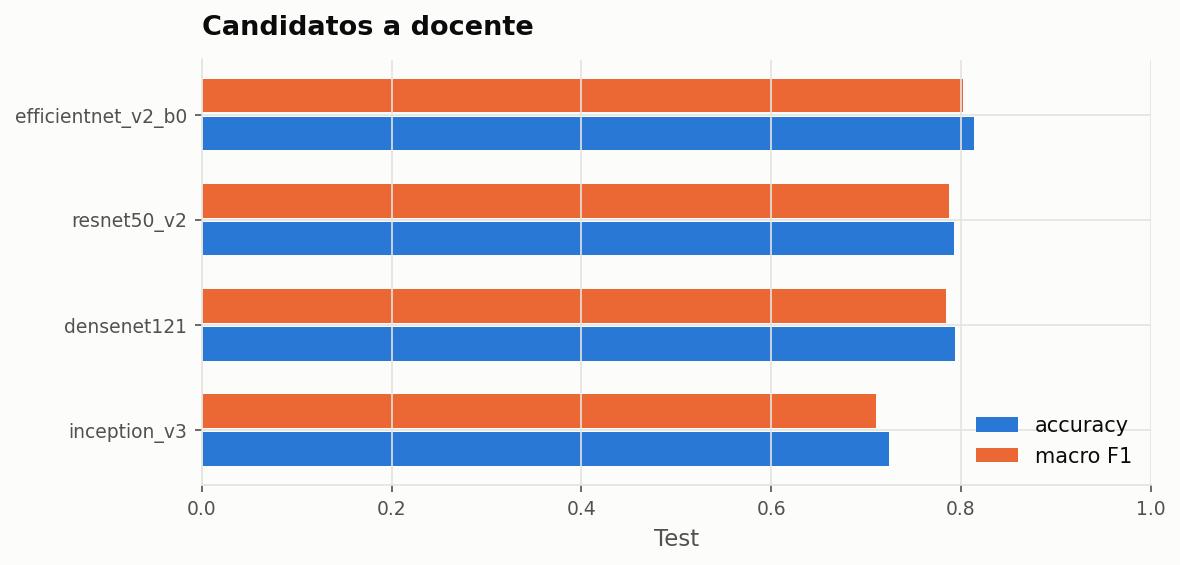

In [4]:
applyStyle()
import matplotlib.pyplot as plt

orden = comparacion.sort_values("test_macro_f1")
y = range(len(orden))

fig, ax = plt.subplots(figsize=(8, 0.6 * len(orden) + 1.5))
ax.barh([i - 0.18 for i in y], orden["test_accuracy"], height=0.32, color=SERIE_1, label="accuracy")
ax.barh([i + 0.18 for i in y], orden["test_macro_f1"], height=0.32, color=SERIE_2, label="macro F1")
ax.set_yticks(list(y), orden["arquitectura"])
ax.set(xlim=(0, 1), xlabel="Test", title="Candidatos a docente")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 3 · Docente elegido

Se promueve, se copia a `outputs/model.keras` y se deja en `teacher.json`
para que las notebooks de destilación lo lean sin elegirlo a mano.

In [5]:
mejor = comparacion.iloc[0]
run = runPorArquitectura[mejor["arquitectura"]]

registro.promoteRun(run["run_id"])
registro.writeJson(registro.OUTPUTS_DIR / "teacher.json", {
    "run_id": run["run_id"],
    "architecture": mejor["arquitectura"],
    "test_accuracy": float(mejor["test_accuracy"]),
    "test_macro_f1": float(mejor["test_macro_f1"]),
    "latencia_ms": float(mejor["latencia_ms"]),
    "parametros_M": float(mejor["parametros_M"]),
})

segundo = comparacion.iloc[1]
print(f"Docente: {mejor['arquitectura']} · macro-F1 {mejor['test_macro_f1']:.4f}")
print(f"Ventaja sobre el siguiente ({segundo['arquitectura']}): "
      f"{mejor['test_macro_f1'] - segundo['test_macro_f1']:+.4f}")

Run promovido: 20260902T015532Z_efficientnet-v2-b0
Docente: efficientnet_v2_b0 · macro-F1 0.8020
Ventaja sobre el siguiente (resnet50_v2): +0.0149


## Resumen

In [6]:
comparacion

,arquitectura,test_accuracy,test_macro_f1,parametros_M,tamano_MB,latencia_ms,minutos_entrenamiento,run_id
0,efficientnet_v2_b0,0.814258,0.802046,6.75,34.7,122.6,183.6,20260902T015532Z_efficientnet-v2-b0
1,resnet50_v2,0.792919,0.787120,24.79,109.7,135.8,449.7,20260904T023029Z_resnet50-v2
2,densenet121,0.793404,0.784358,7.74,38.1,212.7,494.7,20260905T020047Z_densenet121
3,inception_v3,0.724054,0.710476,23.03,103.1,134.9,412.7,20260906T040431Z_inception-v3
